<a href="https://colab.research.google.com/github/vitorjensen/Python_para_Analise_de_Dados/blob/main/Projetos/Classificac%CC%A7a%CC%83o%20de%20Commodities%20Agri%CC%81colas%20com%20Naive%20Bayes/Classifica%C3%A7%C3%A3o%20de%20Commodities%20Agr%C3%ADcolas%20com%20Naive%20Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Importando bibliotecas necessárias
import pandas as pd
import matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
pd.options.display.float_format = '{:.2f}'.format

Processo 1: Importando bases e fazendo o Merge

In [3]:
# Carregando as bases de dados
df_cafe = pd.read_csv('/content/drive/MyDrive/Commodities_Cepea_tratadas/cafe.csv')
df_dolar = pd.read_csv('/content/drive/MyDrive/Commodities_Cepea_tratadas/dolar.csv')
df_soja = pd.read_csv('/content/drive/MyDrive/Commodities_Cepea_tratadas/soja.csv')

In [4]:
# Merge das bases de dados

primeiro_merge = pd.merge(df_cafe, df_soja, on='Data', how='inner')
df_merged = pd.merge(primeiro_merge, df_dolar, on='Data', how='inner')


In [ ]:
# Exibindo dados
display(df_merged)

Processo 2: Tratamento para os campos de Data e Preço

In [ ]:
df_merged.info()

In [ ]:
# Definindo a coluna Data com o tipo data

df_merged['Data'] = pd.to_datetime(df_merged['Data'])
df_merged

In [ ]:
# Definindo Preços como numéricos e com duas casas decimais
colunas_valores = [coluna for coluna in df_merged.columns if df_merged[coluna].dtype == 'object' and coluna != 'Data']

for coluna in colunas_valores:
    # Remove o ponto (separador de milhar), substitui a vírgula por ponto (decimal) e converte para numérico
    df_merged[coluna] = df_merged[coluna].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    df_merged[coluna] = pd.to_numeric(df_merged[coluna], errors='coerce')

# Exibe as informações e as primeiras linhas para conferência
display(df_merged.info())
display(df_merged.head())

Processo 3: Criando a coluna Investe

In [ ]:
# Definindo a variação mensal para o café e a soja em %

df_merged['Variação Café em %'] = df_merged['Valor_Cafe_em_Reais'].pct_change() * 100
df_merged['Variação Soja em %'] = df_merged['Valor_Soja_em_Reais'].pct_change() * 100
display(df_merged)

In [ ]:
# Criando a coluna Investe

# Eliminando a primeira linha
df_merged = df_merged.drop(0)

def analisar_investe(linha):
  var_cafe = linha['Variação Café em %']
  var_soja = linha['Variação Soja em %']

  if var_cafe <= 0 and var_soja <= 0:
    return 'Nenhum'
  elif var_cafe > var_soja:
    return 'Café'
  else:
    return 'Soja'

df_merged['Investe'] = df_merged.apply(analisar_investe, axis=1)
display(df_merged)


Processo 4: Análise Exploratória

In [ ]:
df_merged.head()

In [ ]:
df_merged.describe()

In [ ]:
df_merged.info()

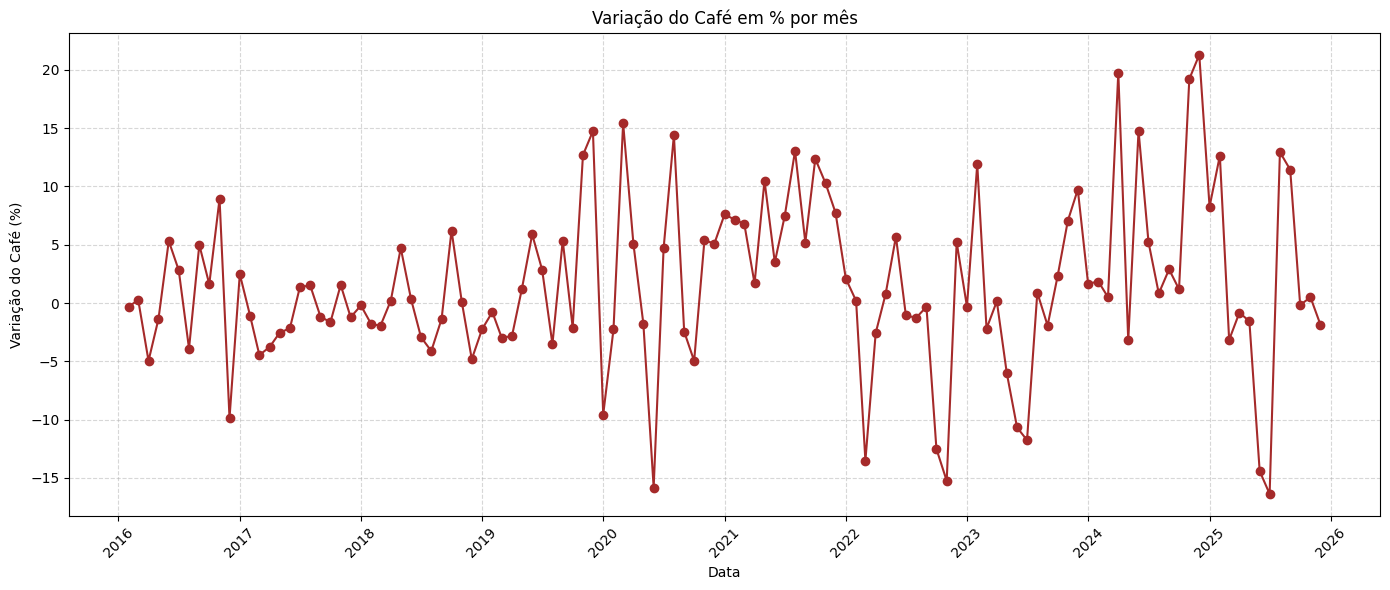

In [12]:

# Plotando gráfico Variação mensaldo Café por mês
plt.figure(figsize=(14, 6))

# Ajustado: Data no eixo X e Variação no eixo Y
plt.plot(df_merged['Data'], df_merged['Variação Café em %'], marker='o', color='brown')

plt.title('Variação do Café em % por mês')
plt.xlabel('Data')
plt.ylabel('Variação do Café (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

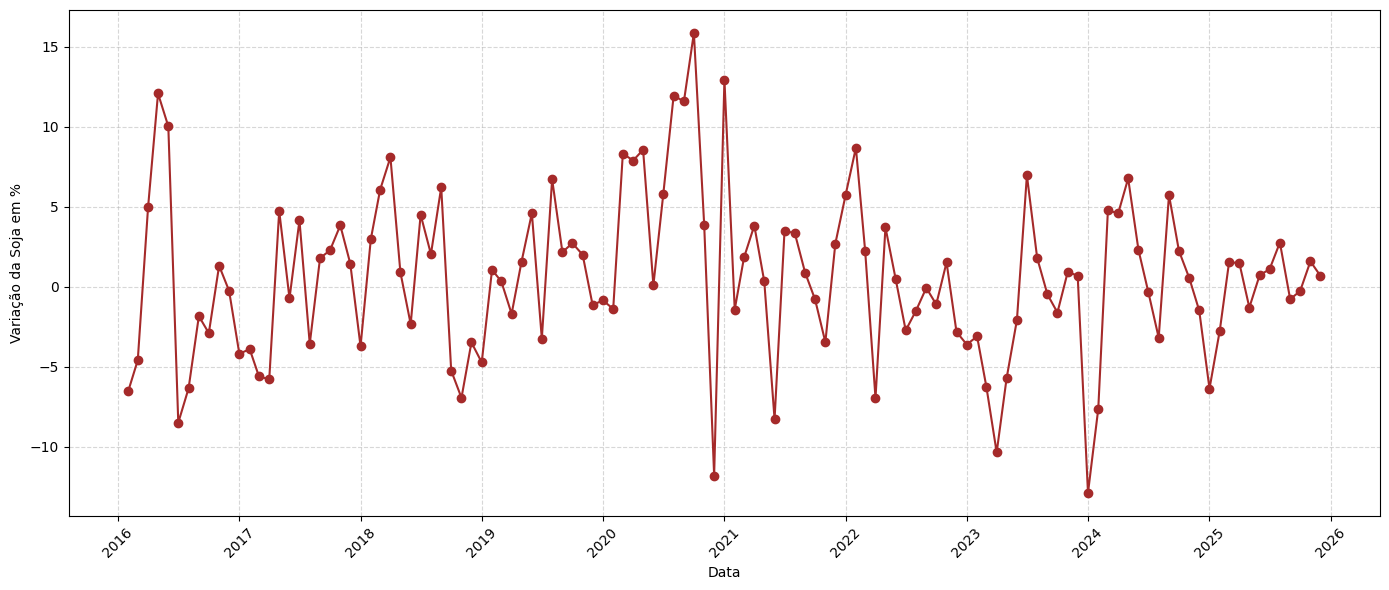

In [23]:
# Gerando gráfico da variação mensal da Soja por mês

plt.figure(figsize=(14, 6))
plt.plot(df_merged['Data'], df_merged['Variação Soja em %'], marker='o', color='brown')
plt.xlabel("Data")
plt.ylabel("Variação da Soja em % por mês")
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

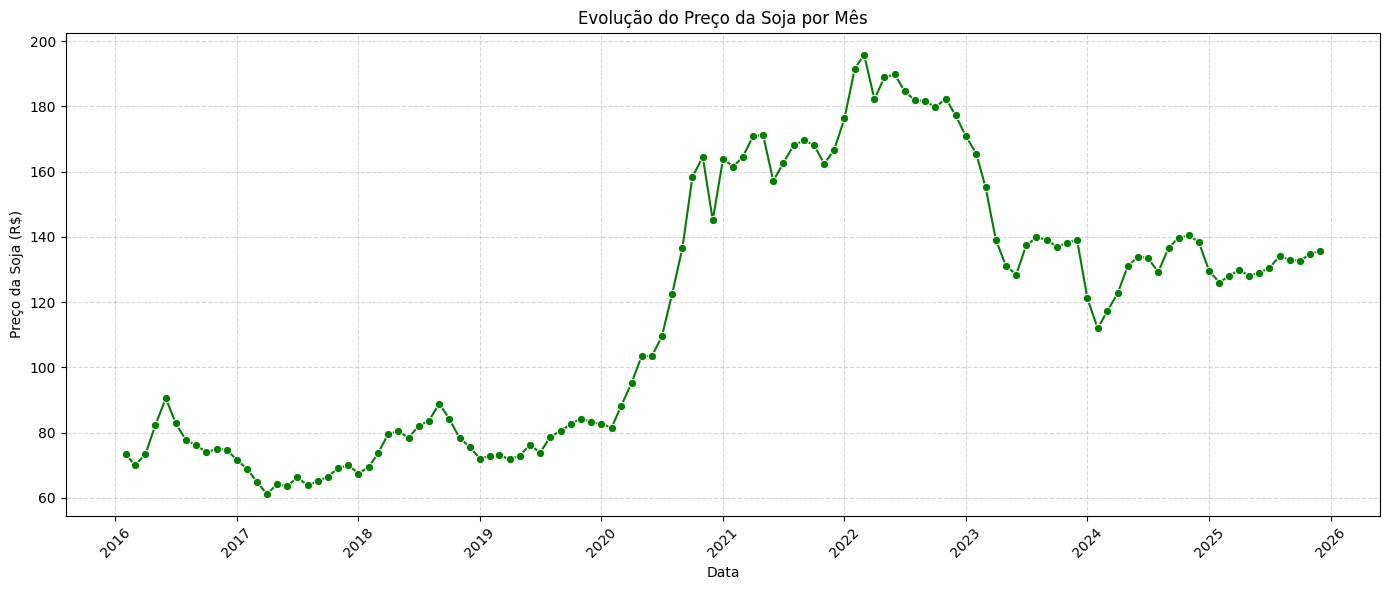

In [18]:
# Evolução do preço da soja por mês
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_merged, x='Data', y='Valor_Soja_em_Reais', color='green', marker='o')

plt.title('Evolução do Preço da Soja por Mês')
plt.xlabel('Data')
plt.ylabel('Preço da Soja (R$)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

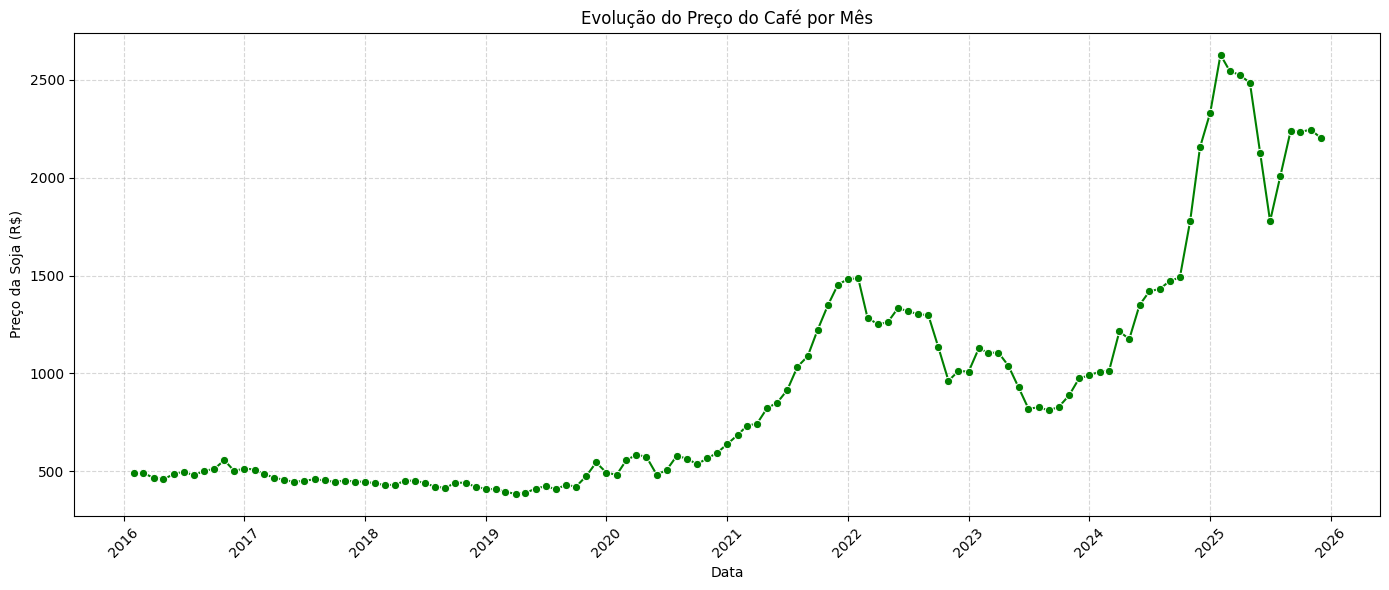

In [28]:
# Evolução do Preço do Café por mês

# Evolução do preço da soja por mês
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_merged, x='Data', y='Valor_Cafe_em_Reais', color='green', marker='o')

plt.title('Evolução do Preço do Café por Mês')
plt.xlabel('Data')
plt.ylabel('Preço da Soja (R$)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

In [37]:
# Visualizando o que compensou mais investir por ano

Recomendacao_Investimento_Cafe = df_merged[df_merged['Investe'] == 'Café'].count().reset_index()
# df_merged['Cafe_Investido_Ano'] = df_merged[df_merged['Investe'] == 'Café'].count()
# df_merged['Ano'] = df_merged['Data'].dt.year
# mais_investe = df_merged.groupby('Ano')['Investe'].count()
display(Recomendacao_Investimento_Cafe)


,index,0
0,Data,49
1,Valor_Cafe_em_Reais,49
2,Valor_Cafe_em_Dolar,49
3,Valor_Soja_em_Reais,49
4,Valor_Soja_em_Dolar,49
5,Valor_Dolar_em_Reais,49
6,Variação Café em %,49
7,Variação Soja em %,49
8,Investe,49
9,Ano,49


In [38]:
# 1. Garantir que a coluna 'Ano' existe e está no formato correto
df_merged['Ano'] = df_merged['Data'].dt.year

# 2. Agrupar por 'Ano' e 'Investe' e contar as ocorrências
analise_anual = df_merged.groupby(['Ano', 'Investe']).size().reset_index(name='Quantidade')

# 3. Pivotar a tabela para ficar mais fácil de ler (com anos nas linhas e ativos nas colunas)
tabela_comparativa = analise_anual.pivot(index='Ano', columns='Investe', values='Quantidade').fillna(0).astype(int)

# Exibir a tabela comparativa
display(tabela_comparativa)

Investe,Café,Nenhum,Soja
Ano,,,
2016,5,3,3
2017,2,4,6
2018,4,2,6
2019,5,2,5
2020,4,2,6
2021,10,0,2
2022,2,5,5
2023,5,5,2
2024,8,0,4


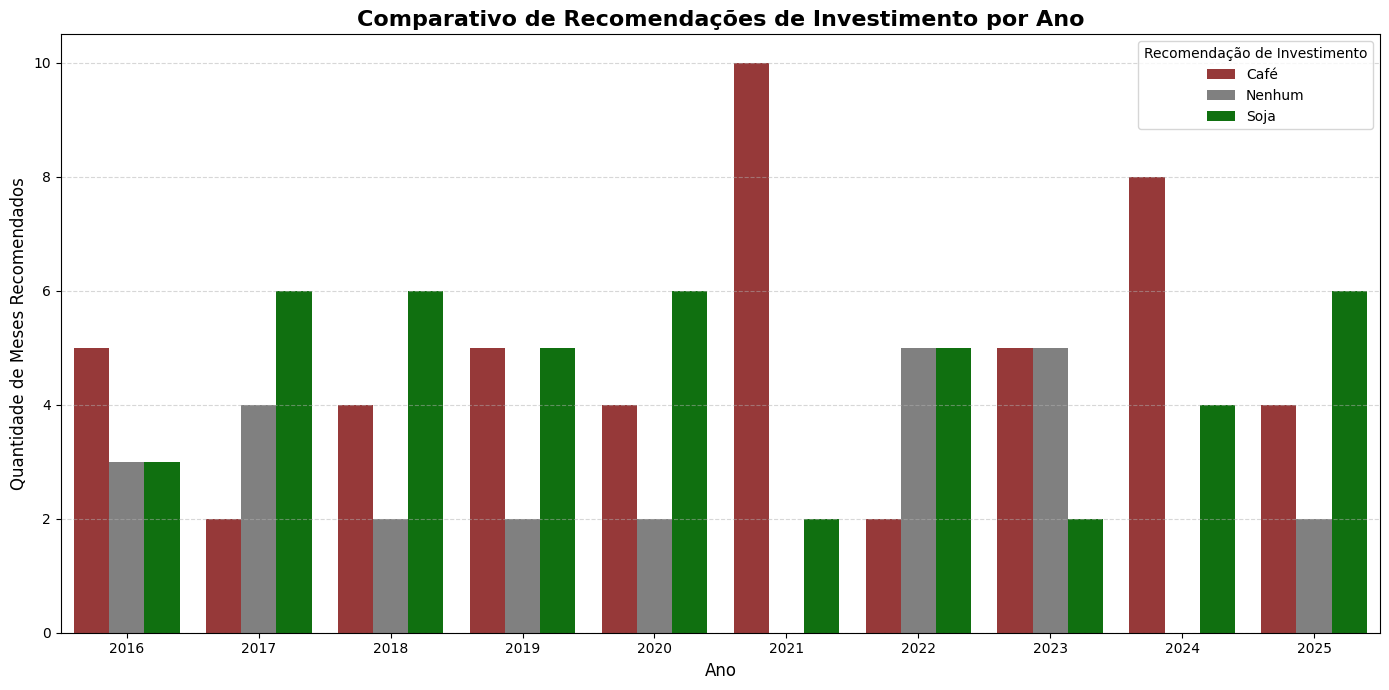

In [39]:
# Resetar o índice para transformar o 'Ano' de volta em coluna para facilitar a plotagem no seaborn
df_plot = tabela_comparativa.reset_index()

# Transformar o formato da tabela de 'largo' para 'longo' (melt) para o Seaborn criar as legendas automaticamente
df_melted = df_plot.melt(id_vars='Ano', var_name='Recomendação', value_name='Quantidade')

# Criar o gráfico de barras agrupadas
plt.figure(figsize=(14, 7))
sns.barplot(data=df_melted, x='Ano', y='Quantidade', hue='Recomendação', palette=['brown', 'gray', 'green'])

plt.title('Comparativo de Recomendações de Investimento por Ano', fontsize=16, fontweight='bold')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Quantidade de Meses Recomendados', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Recomendação de Investimento')
plt.tight_layout()
plt.show()